In [2]:
import pandas as pd
from sklearn import linear_model
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

plt.rcParams.update({'figure.figsize': (12.0, 8.0)})
plt.rcParams.update({'font.size': 14})

In [3]:
X = pd.read_csv("../data/X_train.csv").drop(['id'], axis=1)
y = pd.read_csv("../data/y_train.csv").drop(['id'], axis=1)

# impute data with average value 
X = X.fillna(X.median())
X = X.drop(X.loc[:, X.var()<0.01].columns, axis=1) # only use columns with variance
X_norm =(X-X.mean())/X.std() # normalise the data

# test train split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [4]:
# Feature selection with Lasso
n = 100
lasso_result = pd.DataFrame(columns=['alpha', 'R^2', '#coef'], index=range(n))
i = 0
for a in np.linspace(0,1.5,n):
    lasso = linear_model.Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    
    lasso_result.loc[i, 'alpha'] = a
    lasso_result.loc[i, 'R^2'] = lasso.score(X_test, y_test)
    lasso_result.loc[i, '#coef'] = sum(abs(lasso.coef_) > 0.01)

    i+=1




C:\Users\juliu\AppData\Local\Temp/ipykernel_12708/3072469572.py:7: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso.fit(X_train, y_train)
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.246e+03, tolerance: 9.180e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Us

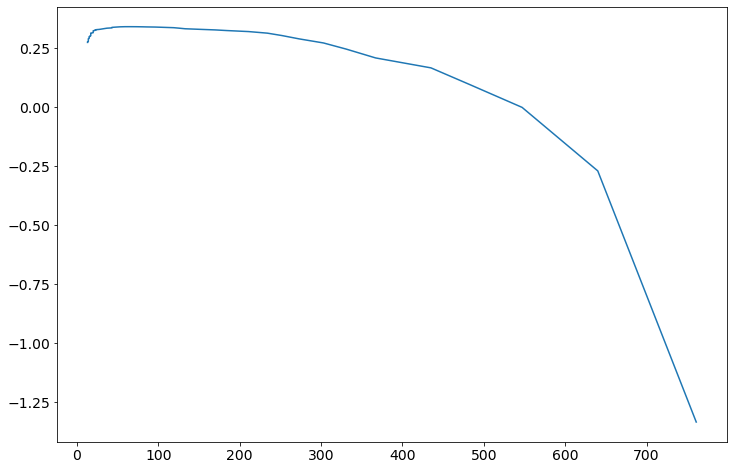

In [5]:
import matplotlib.pyplot as plt
plt.plot(lasso_result['#coef'], lasso_result['R^2'])

In [6]:
lasso_result

,alpha,R^2,#coef
0,0.0,-1.333675,761
1,0.015152,-0.270527,640
2,0.030303,-0.001621,547
3,0.045455,0.095942,482
4,0.060606,0.165647,435
...,...,...,...
95,1.439394,0.278209,14
96,1.454545,0.277047,14
97,1.469697,0.275867,13
98,1.484848,0.274656,13


In [7]:
lasso = linear_model.Lasso(alpha=0.6)
lasso.fit(X_train, y_train)
pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.01], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.01]}).sort_values(by='coef', ascending=False)

,variable,coef
21,x785,1.417338
1,x85,0.975061
7,x302,0.739665
9,x315,0.463742
8,x309,0.447999
20,x779,0.303803
5,x214,0.244894
4,x187,0.129180
15,x687,0.052345
18,x726,-0.093024


# Feature Importance RF

In [9]:
# Let's load the packages
import numpy as np
import pandas as pd
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import shap
from matplotlib import pyplot as plt

# Random forest feature importance
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train.values.ravel())

RandomForestRegressor()

Text(0.5, 0, 'Random Forest Feature Importance')

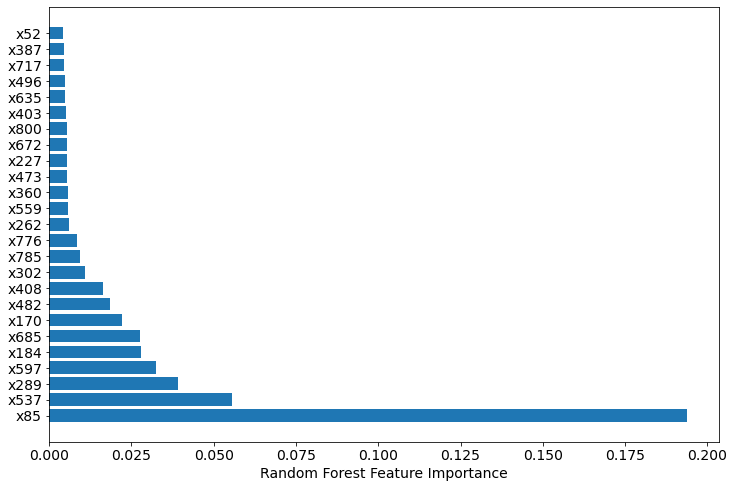

In [10]:
top = 25
sorted_idx = rf.feature_importances_.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

In [11]:
# other form of feature importance
perm_importance = permutation_importance(rf, X_test, y_test)

Text(0.5, 0, 'Permutation Importance')

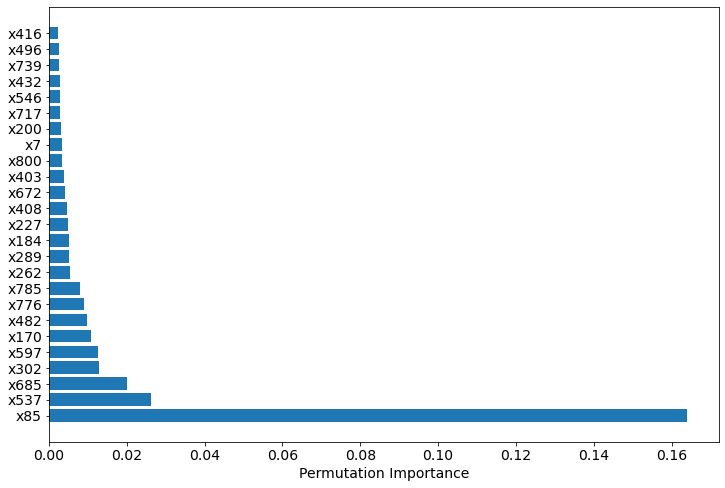

In [12]:
sorted_idx = perm_importance.importances_mean.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

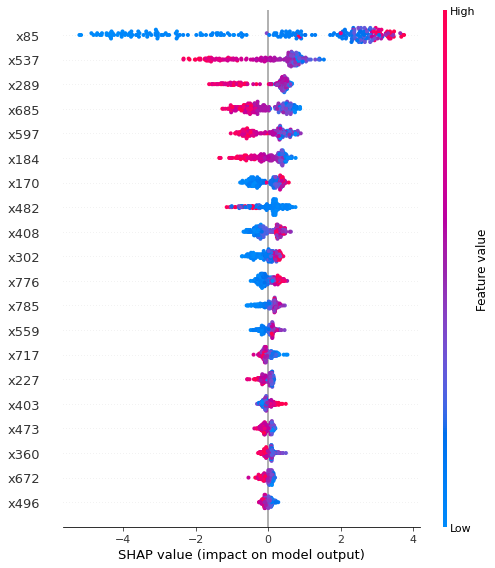

In [13]:
# third method of feature importance
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test) # , plot_type="bar"